In [33]:
import os
import asyncio
import asyncpg
import pandas as pd
from dotenv import load_dotenv
import json

# Load environment variables from .env file
load_dotenv('../server/.env')

# Get database URL from environment
database_url = os.getenv('DATABASE_URL')

async def fetch_data():
    # Connect to the database
    conn = await asyncpg.connect(database_url)
    
    # Fetch log table data
    records = await conn.fetch('SELECT * FROM log')
    
    # Convert to DataFrame
    if records:
        log_df = pd.DataFrame(records, columns=records[0].keys())
    else:
        log_df = pd.DataFrame()
    
    await conn.close()
    return log_df

# Run the async function
log_df = await fetch_data()

log_df = log_df[log_df.deleted_at.isna()]
log_df["data"] = log_df["data"].apply(lambda x: json.loads(x))

log_df.head()

,id,created_at,updated_at,deleted_at,text,data,version
6,01JM15636T586W3SPBTK9Z5YQ1,2025-02-14T02:39:12.090Z,2025-02-14T02:39:12.090Z,None,had a hot chocolate,"[{'item': 'hot chocolate', 'action': 'drank', ...",80
15,01JM2CTWX8TBXB1NHD4BV9R3KA,2025-02-14T14:12:01.000Z,2025-02-14T14:12:01.000Z,None,Tried to poop but couldn’t,"[{'effort': 'high', 'schema': 'pooped', 'poopT...",88
17,01JM2K7HFWZVCAPJFR75VCE0HS,2025-02-14T16:03:48.000Z,2025-02-14T16:03:48.000Z,None,Stomach feeling a bit unsettled,"[{'schema': 'symptom', 'startedAt': '2025-02-1...",90
21,01JM2M1P2M8BAD8EJ4XFM7NH2Y,2025-02-14T16:18:03.000Z,2025-02-14T16:18:03.000Z,None,Small poop. A little wet,"[{'effort': 'low', 'schema': 'pooped', 'poopTy...",91
22,01JM2VK0XF7Y22PK1M9DJBZPXQ,2025-02-14T18:29:54.000Z,2025-02-14T18:29:54.000Z,None,Vegetable and chickpea soup and 1 glass of water,"[{'item': 'vegetable and chickpea soup', 'acti...",92


In [44]:
events_df = log_df.explode("data")
events_df["source_text"] = events_df["text"]
events_df["started_at"] = events_df["data"].apply(lambda x: x.get("startedAt", None))
events_df = events_df[["started_at", "data", "source_text"]]
events_df.sort_values("started_at", ascending=True).tail(10)

,started_at,data,source_text
142,2025-02-22T19:53:58-05:00,"{'item': 'shrimp and mango on rice', 'action':...",Ate shrimp and mango on rice 2h ago
144,2025-02-22T23:15:47-05:00,"{'effort': 'high', 'schema': 'pooped', 'poopTy...",Tried to poop but couldn’t
143,2025-02-22T23:18:36-05:00,"{'item': 'magnesium', 'action': 'took', 'amoun...",Took 1 magnesium
148,2025-02-23T05:38:22-05:00,"{'item': 'vitamin D', 'action': 'took', 'amoun...",Took vitamin D and omega 3
148,2025-02-23T05:38:22-05:00,"{'item': 'omega 3', 'action': 'took', 'amount'...",Took vitamin D and omega 3
145,2025-02-23T08:50:54-05:00,"{'item': 'water', 'action': 'drank', 'amount':...",Drank 500ml water
146,2025-02-23T09:54:01-05:00,"{'item': 'dandelion tea', 'action': 'drank', '...",Drank dandelion tea
147,2025-02-23T10:38:00-05:00,"{'item': 'egg omelette', 'action': 'ate', 'amo...",Ate 2 egg omelette
149,2025-02-23T11:53:42-05:00,"{'item': 'hot chocolate', 'action': 'drank', '...",Drank hot chocolate 30min ago
101,2025-02-23T12:23:48-05:00,"{'effort': 'high', 'schema': 'pooped', 'poopTy...",Small poop. High effort


In [45]:
events_df.sort_values("started_at", ascending=True).to_csv("events.csv", index=False)

In [58]:
import pint
ureg = pint.UnitRegistry()

water_df = events_df[events_df["data"].apply(lambda x: "water" in x.get("item", "") or "tea" in x.get("item", ""))]
water_df = water_df.sort_values("started_at", ascending=True).reset_index(drop=True)
water_df["amount"] = water_df["data"].apply(lambda x: x.get("amount", ""))

water_df["normalized_amount"] = water_df["amount"] \
    .apply(lambda x: "1 cup" if x == "1" or x == "1 serving" else x) \
    .apply(lambda x: "500 millileters" if x == "1 glass" else x)

# Convert string measurements to pint quantities
def parse_measurement(measurement_str):
    try:
        # Handle empty/invalid values
        if not measurement_str or pd.isna(measurement_str):
            return None
        
        # Clean up the input string
        measurement_str = measurement_str.lower().replace('millileters', 'milliliters')
        
        # Parse the measurement
        return ureg.Quantity(measurement_str)
    except:
        return None

# Add new columns for the parsed quantity and everything in milliliters
water_df["quantity"] = water_df["normalized_amount"].apply(parse_measurement)
water_df["ml"] = water_df["quantity"].apply(lambda x: x.to('milliliters').magnitude if x else None)

water_df

,started_at,data,source_text,amount,normalized_amount,quantity,ml
0,2025-02-14T10:30:53-05:00,"{'item': 'tea', 'action': 'drank', 'amount': '...",30min ago had 2 egg omelette and half apple an...,1,1 cup,1 cup,236.588236
1,2025-02-14T13:29:54-05:00,"{'item': 'water', 'action': 'drank', 'amount':...",Vegetable and chickpea soup and 1 glass of water,1 glass,500 millileters,500 milliliter,500.000000
2,2025-02-14T16:17:34-05:00,"{'item': 'water', 'action': 'drank', 'amount':...",Drank 1L water,1 liter,1 liter,1 liter,1000.000000
3,2025-02-14T21:00:00-05:00,"{'item': 'water', 'action': 'drank', 'amount':...","Last night had: 2 pieces of pizza, a salad, ti...",1 glass,500 millileters,500 milliliter,500.000000
4,2025-02-15T08:30:00-05:00,"{'item': 'decaf tea', 'action': 'drank', 'amou...","at 8:30am, at toast with peanut butter, a bana...",1 cup,1 cup,1 cup,236.588236
5,2025-02-15T13:26:03-05:00,"{'item': 'water', 'action': 'drank', 'amount':...",Vegetable and chickpea soup and 1 glass of water,1 glass,500 millileters,500 milliliter,500.000000
6,2025-02-15T17:49:14-05:00,"{'item': 'water', 'action': 'drank', 'amount':...","Ran 20k in 2.5 hours, ate 4 gel packs, drank 1...",1 liter,1 liter,1 liter,1000.000000
7,2025-02-15T18:12:26-05:00,"{'item': 'water', 'action': 'drank', 'amount':...",Drank half liter of water,0.5 liters,0.5 liters,0.5 liter,500.000000
8,2025-02-15T18:13:36-05:00,"{'item': 'dandelion tea', 'action': 'drank', '...",1 cup dandelion tea,1 cup,1 cup,1 cup,236.588236
9,2025-02-16T09:27:23-05:00,"{'item': 'dandelion tea', 'action': 'drank', '...","Breakfast with 1 toast, 2 eggs, 2 bacon, and h...",1 cup,1 cup,1 cup,236.588236


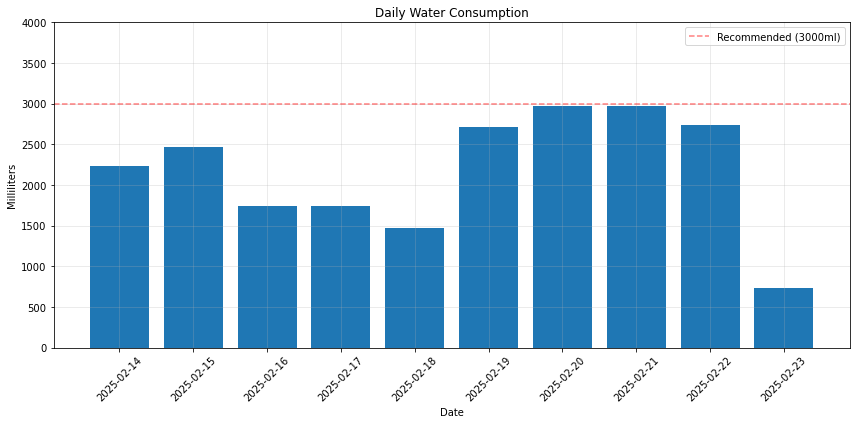

In [63]:
# Group by date and sum milliliters consumed
daily_water = water_df.copy()
daily_water['date'] = pd.to_datetime(daily_water['started_at']).dt.date
daily_consumption = daily_water.groupby('date')['ml'].sum().reset_index()

# Import matplotlib
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 6))
plt.bar(daily_consumption['date'], daily_consumption['ml'])
plt.title('Daily Water Consumption')
plt.xlabel('Date')
plt.ylabel('Milliliters')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.ylim(0, 4000)  # Set y-axis limit to 4000

# Add a horizontal line at recommended daily intake (2000ml)
plt.axhline(y=3000, color='r', linestyle='--', alpha=0.5, label='Recommended (3000ml)')
plt.legend()

plt.tight_layout()
plt.show()


In [72]:
for poop in events_df[events_df["data"].apply(lambda x: x.get("schema", "") == "pooped")]["data"].sample(10):
    print(poop)

{'effort': 'high', 'schema': 'pooped', 'poopType': 0, 'startedAt': '2025-02-22T23:15:47-05:00'}
{'effort': 'high', 'schema': 'pooped', 'poopType': 0, 'startedAt': '2025-02-15T22:19:06-05:00'}
{'effort': 'high', 'schema': 'pooped', 'poopType': 0, 'startedAt': '2025-02-16T08:14:56-05:00'}
{'effort': 'high', 'schema': 'pooped', 'poopType': 1, 'startedAt': '2025-02-19T18:05:47-05:00'}
{'effort': 'high', 'schema': 'pooped', 'poopType': 0, 'startedAt': '2025-02-19T23:20:38-05:00'}
{'effort': 'high', 'schema': 'pooped', 'poopType': 0, 'startedAt': '2025-02-19T17:18:52-05:00'}
{'effort': 'medium', 'schema': 'pooped', 'poopType': 4, 'startedAt': '2025-02-15T17:15:15-05:00'}
{'effort': 'medium', 'schema': 'pooped', 'poopType': 5, 'startedAt': '2025-02-20T10:31:00-05:00'}
{'effort': 'medium', 'schema': 'pooped', 'poopType': 3, 'startedAt': '2025-02-17T10:30:46-05:00'}
{'effort': 'low', 'schema': 'pooped', 'poopType': 6, 'startedAt': '2025-02-14T11:18:03-05:00'}


In [91]:

poop_df = events_df[events_df["data"].apply(lambda x: x.get("schema", "") == "pooped")].reset_index(drop=True)
poop_df["poop_type"] = poop_df["data"].apply(lambda x: x.get("poopType", ""))
poop_df["effort"] = poop_df["data"].apply(lambda x: x.get("effort", ""))
poop_df["effort_normalized"] = poop_df["effort"].apply(lambda x: 1 if x == "low" else 2 if x == "medium" else 3 if x == "high" else None)
# 0, 1, 2, 3
# none, small, medium, large
def parse_amount(source_text):
    source_text = source_text.lower()
    if "couldn" in source_text or "none" in source_text:
        return "none"
    elif "small" in source_text or "little" in source_text:
        return "small"
    else:
        return "normal"
poop_df["amount"] = poop_df["source_text"].apply(lambda x: parse_amount(x or ""))
poop_df["amount_normalized"] = poop_df["amount"].apply(lambda x: 0 if x == "none" else 0.5 if x == "small" else 1 if x == "normal" else None)
poop_df = poop_df.sort_values("started_at", ascending=True).reset_index(drop=True)

poop_df

,started_at,data,source_text,poop_type,effort,effort_normalized,amount,amount_normalized
0,2025-02-13T22:15:41-05:00,"{'effort': 'high', 'schema': 'pooped', 'poopTy...",Tough poop. Long time. Small pieces,2,high,3,small,0.5
1,2025-02-14T09:12:01-05:00,"{'effort': 'high', 'schema': 'pooped', 'poopTy...",Tried to poop but couldn’t,1,high,3,none,0.0
2,2025-02-14T11:18:03-05:00,"{'effort': 'low', 'schema': 'pooped', 'poopTyp...",Small poop. A little wet,6,low,1,small,0.5
3,2025-02-14T22:18:16-05:00,"{'effort': 'high', 'schema': 'pooped', 'poopTy...",Difficult poop. No success,1,high,3,normal,1.0
4,2025-02-15T08:19:32-05:00,"{'effort': 'high', 'schema': 'pooped', 'poopTy...",Long poop. Many pieces. Soft. Difficult,6,high,3,normal,1.0
5,2025-02-15T13:09:05-05:00,"{'effort': 'low', 'schema': 'pooped', 'poopTyp...",Pooped. Not much. Med hard. Few small diffuse ...,2,low,1,small,0.5
6,2025-02-15T17:15:15-05:00,"{'effort': 'medium', 'schema': 'pooped', 'poop...",Good poop. Med effort,4,medium,2,normal,1.0
7,2025-02-15T22:19:06-05:00,"{'effort': 'high', 'schema': 'pooped', 'poopTy...",Tried to poop but couldn’t,0,high,3,none,0.0
8,2025-02-16T08:14:56-05:00,"{'effort': 'high', 'schema': 'pooped', 'poopTy...",Tried to poop but couldn’t,0,high,3,none,0.0
9,2025-02-16T10:26:38-05:00,"{'effort': 'medium', 'schema': 'pooped', 'poop...",Partial poop,0,medium,2,normal,1.0


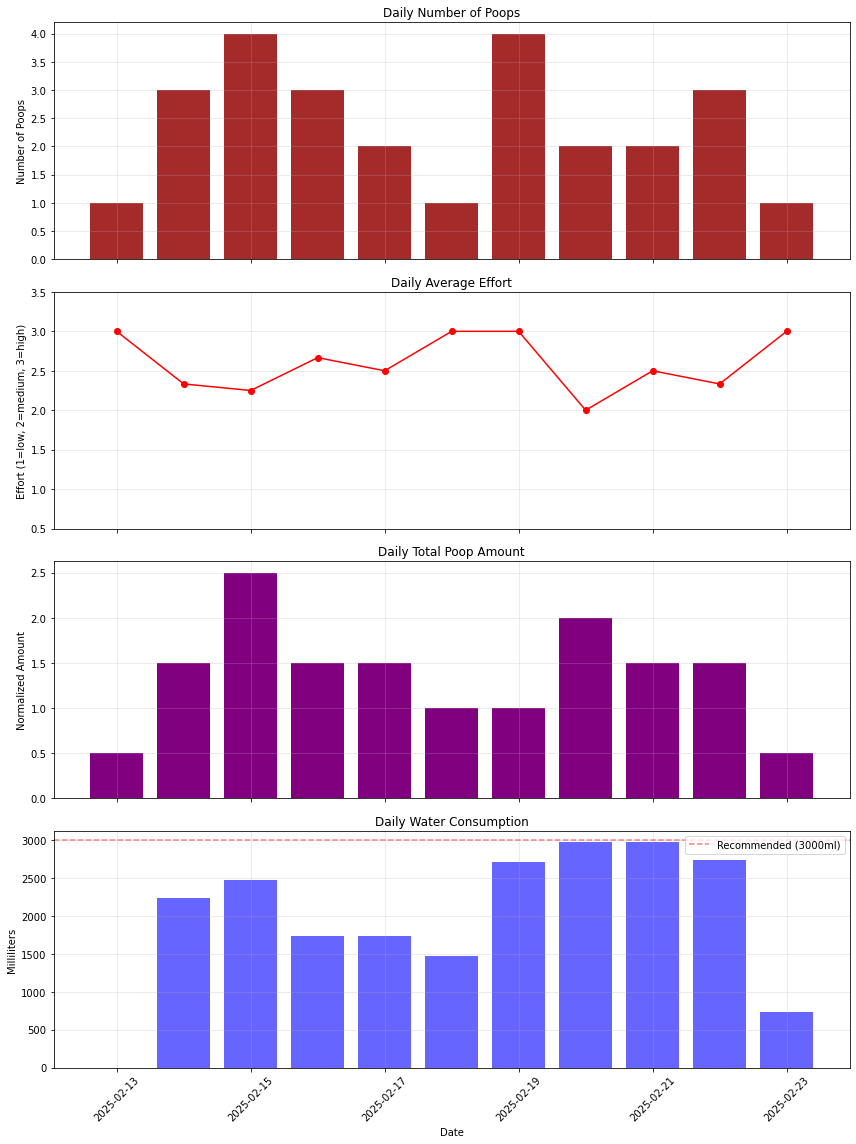

In [92]:
# Convert started_at to date for both dataframes
poop_df['date'] = pd.to_datetime(poop_df['started_at']).dt.date
daily_water['date'] = pd.to_datetime(daily_water['started_at']).dt.date

# Group by date and calculate metrics
daily_stats = poop_df.groupby('date').agg({
    'poop_type': 'count',  # Count number of poops
    'effort_normalized': 'mean',  # Average effort
    'amount_normalized': 'sum'  # Sum of normalized amounts
}).reset_index()

# Get daily water consumption
daily_water_stats = daily_water.groupby('date')['ml'].sum().reset_index()

# Create figure with four subplots sharing x-axis
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

# Plot number of poops
ax1.bar(daily_stats['date'], daily_stats['poop_type'], color='brown')
ax1.set_title('Daily Number of Poops')
ax1.set_ylabel('Number of Poops')
ax1.grid(True, alpha=0.3)

# Plot average effort
ax2.plot(daily_stats['date'], daily_stats['effort_normalized'], color='red', marker='o')
ax2.set_title('Daily Average Effort')
ax2.set_ylabel('Effort (1=low, 2=medium, 3=high)')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.5, 3.5)

# Plot total normalized amount
ax3.bar(daily_stats['date'], daily_stats['amount_normalized'], color='purple')
ax3.set_title('Daily Total Poop Amount')
ax3.set_ylabel('Normalized Amount')
ax3.grid(True, alpha=0.3)

# Plot water consumption
ax4.bar(daily_water_stats['date'], daily_water_stats['ml'], color='blue', alpha=0.6)
ax4.set_title('Daily Water Consumption')
ax4.set_ylabel('Milliliters')
ax4.set_xlabel('Date')
ax4.grid(True, alpha=0.3)
ax4.axhline(y=3000, color='r', linestyle='--', alpha=0.5, label='Recommended (3000ml)')
ax4.legend()

# Rotate x-axis labels
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
